In [1]:
!pip install lightgbm

In [2]:
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score
from sklearn.datasets import load_breast_cancer

In [3]:
data=load_breast_cancer(as_frame=True)
df=data.frame

X=df.drop(columns=["target"])
y=df["target"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

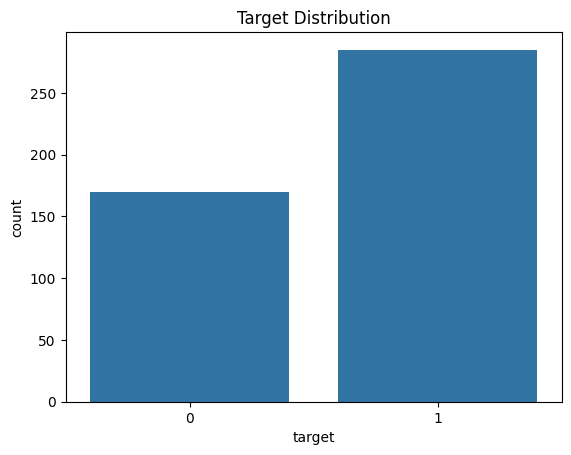

In [4]:
sns.countplot(x=y_train)
plt.title("Target Distribution")
plt.show()

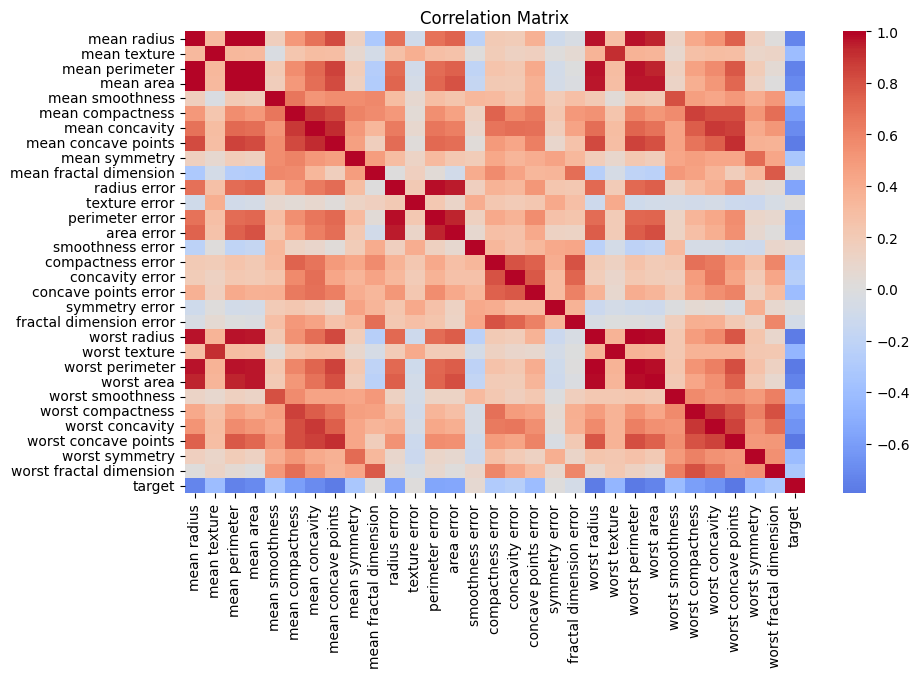

In [6]:
corr=df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr,cmap="coolwarm",center=0)
plt.title("Correlation Matrix")
plt.show()

In [7]:
train_data=lgb.Dataset(X_train,label=y_train)
valid_data=lgb.Dataset(X_test,label=y_test,reference=train_data)

In [8]:
params={
"objective":"binary",
"metric":["auc","binary_logloss"],
"boosting_type":"gbdt",
"learning_rate":0.05,
"num_leaves":31,
"max_depth":-1,
"feature_fraction":0.8,
"bagging_fraction":0.8,
"bagging_freq":5,
"lambda_l1":0.1,
"lambda_l2":0.2,
"min_data_in_leaf":20,
"verbose":-1
}

In [9]:
model=lgb.train(
params,
train_data,
num_boost_round=1000,
valid_sets=[train_data,valid_data],
valid_names=["train","valid"],
callbacks=[lgb.early_stopping(50)]
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[22]	train's auc: 0.996956	train's binary_logloss: 0.238247	valid's auc: 0.993056	valid's binary_logloss: 0.257051


In [10]:
y_pred_prob=model.predict(X_test,num_iteration=model.best_iteration)
y_pred=(y_pred_prob>0.5).astype(int)

In [11]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
auc=roc_auc_score(y_test,y_pred_prob)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("AUC:",auc)

Accuracy: 0.9473684210526315
Precision: 0.9583333333333334
Recall: 0.9583333333333334
F1 Score: 0.9583333333333334
AUC: 0.9930555555555556


In [12]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



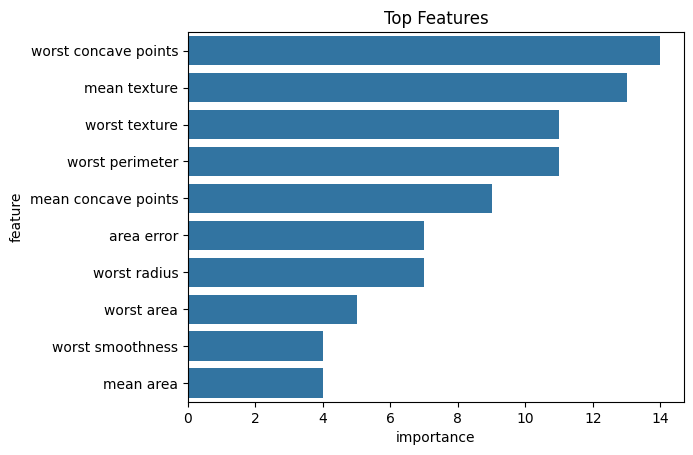

In [13]:
importance=pd.DataFrame({
"feature":X.columns,
"importance":model.feature_importance()
}).sort_values(by="importance",ascending=False)

sns.barplot(x="importance",y="feature",data=importance.head(10))
plt.title("Top Features")
plt.show()

In [15]:
kf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores=[]

for train_idx,val_idx in kf.split(X,y):
    X_tr,X_val=X.iloc[train_idx],X.iloc[val_idx]
    y_tr,y_val=y.iloc[train_idx],y.iloc[val_idx]

    train_set=lgb.Dataset(X_tr,label=y_tr)
    val_set=lgb.Dataset(X_val,label=y_val)

    model=lgb.train(
        params,
        train_set,
        num_boost_round=500,
        valid_sets=[val_set],
        callbacks=[
            lgb.early_stopping(30),
            lgb.log_evaluation(0)
        ]
    )

    preds=model.predict(X_val)
    scores.append(roc_auc_score(y_val,preds))

print("CV AUC:",np.mean(scores))

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[65]	valid_0's auc: 0.998362	valid_0's binary_logloss: 0.101642
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[15]	valid_0's auc: 0.986079	valid_0's binary_logloss: 0.347201
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[65]	valid_0's auc: 0.990079	valid_0's binary_logloss: 0.121945
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[97]	valid_0's auc: 0.999669	valid_0's binary_logloss: 0.0823977
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[58]	valid_0's auc: 0.992958	valid_0's binary_logloss: 0.121945
CV AUC: 0.9934295913291983
